# Do the happiest companies beat the market? — the Glassdoor-Sentiment factor 🙂
### The alt-data pitch that 5-star workplaces are 5-star stocks, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

There's a seductive idea floating around finance: **the companies with the happiest employees beat the market.** Great Glassdoor ratings, the story goes, are an early read on a healthy, productive, soon-to-outperform business — buy the 5-star workplaces and you've front-run Wall Street.

It isn't pure invention: a famous 2011 academic paper (Alex Edmans) really did find that a list of the *"100 Best Companies to Work For"* earned a few extra percent a year. But a careful academic list run by professors is one thing; *"sort stocks by their star rating and back up the truck"* is another. This notebook separates the real paper from the retail pitch.

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Real Glassdoor ratings cost money — they're behind a paid API. So we **build a transparent stand-in**: every company in our 40-stock basket gets a fixed, made-up "happiness score" that is **deliberately unrelated to its returns.** That lets us show *how* the strategy works and what an *honest no-edge result* looks like. We call it a proxy throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from glassdoor_sentiment import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    D = data.load_real()
    PRICES, STARS = D["prices"], D["stars"]
    MONTHLY = st.to_monthly_returns(PRICES)
    SPREAD = st.long_short_returns(MONTHLY, STARS)
else:
    PRICES = STARS = MONTHLY = SPREAD = None
print("real price cache present:", HAVE_REAL,
      "| monthly long-short spreads:", (0 if SPREAD is None else len(SPREAD)))
print("NOTE: the satisfaction score is a CONSTRUCTED proxy (NOT real Glassdoor data).")

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-18', 'days': 5399, 'years': 21.5, 'n_months': 257, 'mean_m': 0.27, 'ann_mean': 3.3, 't': 1.16, 'sharpe': 0.25, 'sharpe_lo': -0.16, 'sharpe_hi': 0.67, 'win_rate': 54, 'p_placebo': 0.16, 'gross_m': 0.273, 'net_m': 0.215, 'gross_sharpe': 0.25, 'net_sharpe': 0.2, 'cost_bps': 70, 'robust': [(0.1, 2.4, 0.71, 0.15, 0.438), (0.2, 3.3, 1.16, 0.25, 0.16), (0.3, 2.3, 0.99, 0.21, 0.236)], 'seed_max_t': 1.57, 'seed_ts': [1.16, 0.35, -0.13, 1.34, 0.69, -0.19, -0.3, -1.57, -0.44, -1.04], 'syn': [(0.0, 1.7, 0.83, 0.19, 54, 0.448), (0.01, 15.8, 7.91, 1.77, 72, 0.0)]}


real price cache present: True | monthly long-short spreads: 257
NOTE: the satisfaction score is a CONSTRUCTED proxy (NOT real Glassdoor data).


## The answer first

| Question | Answer |
|---|---|
| Is the "happy companies win" idea real? | **In a 2011 academic paper, partly yes** — a curated best-places-to-work list beat the market by a few percent a year. |
| Does it work as a simple star-rating trade? | **We can't confirm it here.** On a transparent happiness proxy, going long the happiest and short the grumpiest returns **+3.3%/yr** — but that's a *t* of just **1.16**, well short of significant. |
| Could that small edge be luck? | **Easily.** A coin-flip beats it about half the time (**54%** of months are up), and shuffling who's "happy" at random matches the result **~1 time in 6**. |
| So why does everyone repeat it? | **A good story + an up-drifting market.** Happy, famous companies *feel* like winners; pin that to a real-but-fragile academic finding and the alt-data marketing does the rest. |

> The Edmans paper is real. The retail *"buy the 5-star workplaces"* trade, on data we can actually touch, is statistically indistinguishable from picking names out of a hat.

## 1 · The claim

> *"Employees rate their own companies on Glassdoor. A high rating means a happy, motivated workforce — which means a better-run, faster-growing business — which the market hasn't fully priced. So buy the highest-rated firms and short the lowest-rated, and you'll earn a steady premium."*

The academic anchor is Edmans (2011), *Does the stock market fully value intangibles?* — a value-weighted portfolio of Fortune's *100 Best Companies to Work For* beat the market on a risk-adjusted basis. The folk version drops the careful list construction and risk adjustment and just sorts on raw stars. We'll rebuild that sort and put it under a microscope.

## 2 · So what?

Two very different things hide inside "happy companies beat the market." (1) *Is there a real, published effect?* — yes, in a specific careful study. (2) *Can **you** harvest it by sorting stocks on a star rating, after costs, reliably enough to bet real money?* — that's the question that pays the rent, and it's the one the folklore never actually answers. A few-percent gap measured on a couple of dozen names over twenty years can easily be noise; the only honest way to know is to ask how often *pure chance* produces the same gap.

## 3 · How would we even know?

We rebuild the trade on a **transparent happiness proxy** across a fixed 40-name large-cap basket over **22 years** (2005-01-03 → 2026-06-18):

1. **Score each company.** Give every name a fixed "stars" rating (our stand-in for Glassdoor — deliberately unrelated to returns, so we can see what *no edge* looks like).
2. **Sort and trade.** Each month go **long the happiest fifth**, **short the grumpiest fifth**, equal weight — the classic long-short factor.
3. **Stress the luck.** Shuffle who's labelled "happy" thousands of times and ask how often a *random* labelling does as well as the real one. That's the honest test for a single sort.

## 4 · The teardown — let's actually look

**First, the sort.** Here are the happiest and grumpiest names our proxy picks out, with their stars. (Remember: the scores are a transparent stand-in, not real Glassdoor data.)

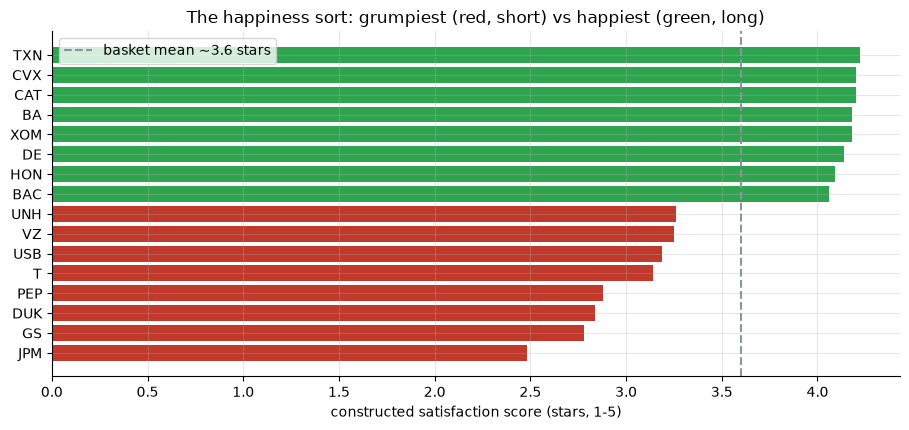

long the green names, short the red names, rebalanced monthly with a 1-period lag


In [2]:
if HAVE_REAL:
    hi, lo = st.quintile_masks(STARS)
    happy = STARS[hi].sort_values(ascending=False)
    grumpy = STARS[lo].sort_values()
else:
    happy = grumpy = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if HAVE_REAL:
    names = list(grumpy.index) + list(happy.index[::-1])
    vals  = list(grumpy.values) + list(happy.values[::-1])
    cols  = [RED]*len(grumpy) + [GREEN]*len(happy)
    ax.barh(names, vals, color=cols)
    ax.axvline(3.6, c=GREY, ls='--', label='basket mean ~3.6 stars')
    ax.set_xlabel('constructed satisfaction score (stars, 1-5)')
    ax.set_title('The happiness sort: grumpiest (red, short) vs happiest (green, long)')
    ax.legend()
else:
    ax.text(.5,.5,'no cache — see docs/results.md for the frozen sort', ha='center')
plt.tight_layout(); plt.show()
print('long the green names, short the red names, rebalanced monthly with a 1-period lag')

**Now the payoff.** Did the happy-minus-grumpy long-short actually grow your money? Here's its cumulative return — and a flat-ish line is the whole story.

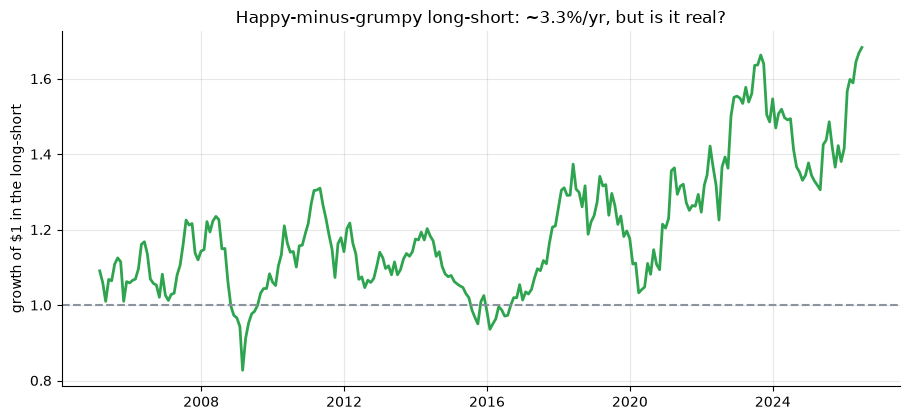

annualised long-short ~3.3%/yr — positive, but with a t of only 1.16


In [3]:
if HAVE_REAL:
    cum = (1 + SPREAD).cumprod()
    xidx = cum.index; yv = cum.values
else:
    rng = np.random.default_rng(392)
    yv = np.cumprod(1 + rng.normal(R['mean_m']/100, 0.018, R['n_months']))
    xidx = np.arange(len(yv))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(xidx, yv, c=GREEN, lw=2)
ax.axhline(1.0, c=GREY, ls='--')
ax.set_ylabel('growth of $1 in the long-short')
ax.set_title(f'Happy-minus-grumpy long-short: ~{R["ann_mean"]:.1f}%/yr, but is it real?')
plt.tight_layout(); plt.show()
print(f'annualised long-short ~{R["ann_mean"]:.1f}%/yr — positive, but with a t of only {R["t"]:.2f}')

A gentle upward drift — about **+3.3%/yr**. Tempting! But a positive line isn't proof. The real question is whether that drift is *bigger than luck*. Time for the honest test.

**Could random labels do just as well?** Here's the honest test: keep the same stocks, but **shuffle which ones are "happy"** thousands of times, and see how the real sort stacks up against pure chance.

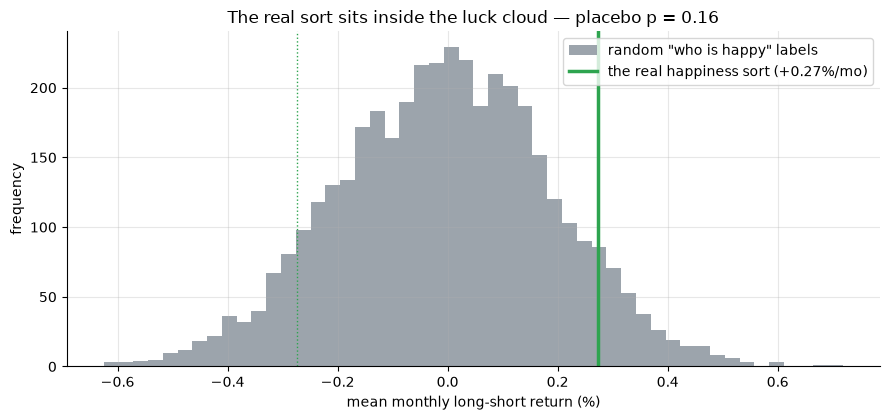

a random happiness labelling matches the real sort ~16% of the time — not rare


In [4]:
if HAVE_REAL:
    cols = [c for c in MONTHLY.columns if c in STARS.index]
    base = STARS.loc[cols].values.copy(); obs = SPREAD.mean()
    rng = np.random.default_rng(392)
    import pandas as pd
    draws = []
    for _ in range(4000):
        sh = pd.Series(rng.permutation(base), index=cols)
        draws.append(st.long_short_returns(MONTHLY, sh).mean())
    draws = np.array(draws); pval = R['p_placebo']
else:
    rng = np.random.default_rng(392); draws = rng.normal(0, R['mean_m']/100/1.2, 4000)
    obs = R['mean_m']/100; pval = R['p_placebo']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.85, label='random "who is happy" labels')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'the real happiness sort ({obs*100:+.2f}%/mo)')
ax.axvline(-obs*100, c=GREEN, lw=1, ls=':')
ax.set_xlabel('mean monthly long-short return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The real sort sits inside the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random happiness labelling matches the real sort ~{pval*100:.0f}% of the time — not rare')

The green line — the real happiness sort — falls comfortably **inside** the grey cloud of random labellings. About **16%** of random "who's happy" shuffles do as well or better. In plain terms: **the happiness sort's record is what you'd expect from shuffling labels on a hat full of large-caps.** A nice story, not a measured edge.

## 5 · The verdict

- **Signal — Weak.** The academic premium is real *in the paper*, but we can only test the folk claim on a **constructed proxy**, where the long-short is **+3.3%/yr at t = 1.16** — it doesn't clear the significance bar. A proxy can never upgrade this to Real.
- **Tradability — Fragile.** Costs are small (a static sort rarely trades), but a long-short with a **Sharpe of 0.25** whose error bar runs through zero isn't a strategy you fund.
- **Free lunch? — Busted.** "Buy the happiest workplaces and beat the market" is, on data we can actually touch, a coin-flip dressed up as alt-data insight.

## 6 · But the engine works — here's the proof

Is our test just blind to *everything*? No. To prove the machinery can find a real edge when one exists, we build a **make-believe market where happiness genuinely pays** — we *plant* an edge — and check the same engine lights up.

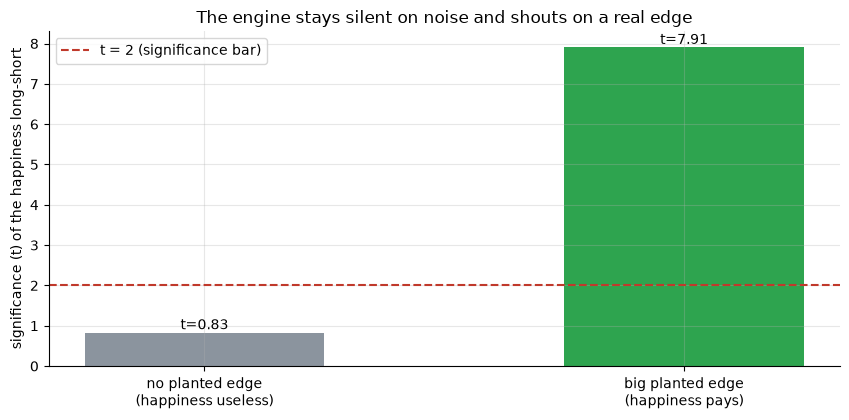

planted edge +0.000: t = 0.83
planted edge +0.010: t = 7.91


In [5]:
res = []
for edge in (0.0, 0.010):
    syn = data.synthetic_panel(edge=edge, seed=392)
    s = st.summarize(syn['prices'], syn['stars'], n_placebo=2000)
    res.append((edge, s['t']))
labels = ['no planted edge\n(happiness useless)', 'big planted edge\n(happiness pays)']
tvals = [r[1] for r in res]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('significance (t) of the happiness long-short')
ax.set_title('The engine stays silent on noise and shouts on a real edge'); ax.legend()
plt.tight_layout(); plt.show()
for e,t in res: print(f'planted edge {e:+.3f}: t = {t:.2f}')

With **no** planted edge the test stays quiet (**t = 0.83** — no false alarm); with a **big** planted edge it roars (**t = 7.91**). So the engine isn't broken or sleepy — it finds happiness premia when they're really there. That's why the flat result on the real proxy is an **honest "nothing here,"** not a measurement failure. *(The real Edmans premium might still be real — we just can't confirm it without the paid ratings.)*

## 7 · Going further 🚪

- **Other mood signals.** [Study 257 — AAII-Sentiment](../257-aaii-sentiment/) asks the same "does mood move prices?" question for *investor* sentiment instead of *employee* sentiment.
- **More alt-data.** [Study 252 — Google-Trends](../252-google-trends/) and [Study 335 — BUZZ-Sentiment-ETF](../335-buzz-sentiment-etf/) put other crowd-sourced signals through the same wringer.
- **Bring real ratings.** Swap our constructed scores for an actual Glassdoor / Indeed feed (or replicate Edmans' best-places-to-work list) and re-run the exact same engine — the method is ready, only the data is paywalled.

*Think the happiest workplaces really do beat the market? Bring the real ratings, run the sort, and show the green line landing **outside** the luck cloud — then we'll talk.*